# Read and plot the original source

Same complete `Fig_2B` readout and plotting options as `read_atst.ipynb`. Source ranges and condition annotations remain explicit; no ATST file is read. Matplotlib plots the source values directly.


In [1]:
import math
import matplotlib.pyplot as plt
import pandas as pd
from openpyxl import load_workbook

readout_id = "Fig_2B"
rows, curves = [], []

sheet = load_workbook(
    "read_shared_data/sources/aem.02402-24-s0002.xlsx", read_only=True, data_only=True
)["Fig 2B"]
time = [row[0].value for row in sheet["A2:A11"]]
for phage, signals, first in [
    ("", "", 2),
    ("", "3OC12-HSL 0.5 uM + C4-HSL 0.4 uM", 5),
    ("phiPA2", "", 8),
    ("phiPA2", "3OC12-HSL 0.5 uM + C4-HSL 0.4 uM", 11),
]:
    for replicate, column in enumerate(range(first, first + 3), 1):
        rows.append(
            {
                "type": "phage_exposed" if phage else "uninfected_control",
                "phage_id": phage,
                "moi": "0.01" if phage else "0",
                "signaling_molecules": signals,
                "replicate": str(replicate),
            }
        )
        curves.append(
            pd.Series([sheet.cell(r, column).value for r in range(2, 12)], index=time)
        )

# Local curve IDs preserve source order; different time grids align without interpolation.
layout = pd.DataFrame(rows)
layout["curve_id"] = [f"curve_{i}" for i in range(1, len(rows) + 1)]
readings = pd.concat(curves, axis=1).sort_index()
readings.columns = layout["curve_id"]
readings = readings.rename_axis("Time").reset_index()


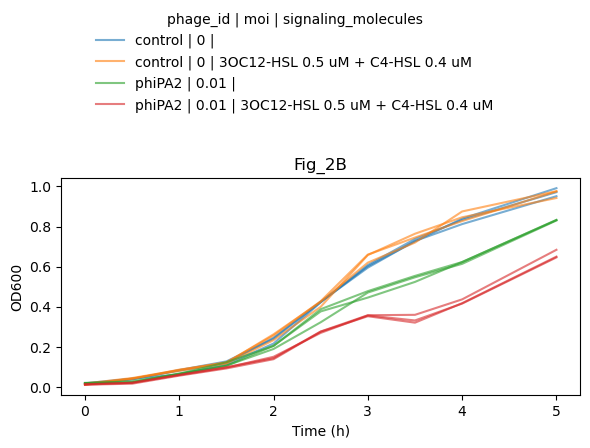

In [2]:
panels = [(None, layout)]
ncols = min(2, len(panels))
nrows = math.ceil(len(panels) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4.5 * nrows), squeeze=False)
palette = plt.rcParams["axes.prop_cycle"].by_key()["color"]
condition_colors = {}

for ax, (panel, panel_layout) in zip(axes.flat, panels):
    for condition, group in panel_layout.groupby(["phage_id", "moi", "signaling_molecules"], sort=False):
        if condition not in condition_colors:
            condition_colors[condition] = palette[len(condition_colors) % len(palette)]
        color = condition_colors[condition]
        label = " | ".join("control" if index == 0 and (pd.isna(value) or value == "") else str(value)
                           for index, value in enumerate(condition))
        values = readings[group["curve_id"]]
        for index, curve_id in enumerate(group["curve_id"]):
            ax.plot(
                readings["Time"],
                readings[curve_id],
                color=color,
                alpha=0.6,
                label=label if index == 0 else None,
            )
    ax.set_xlabel("Time (h)")
    ax.set_ylabel("OD600")
    ax.set_title(readout_id)

for ax in list(axes.flat)[len(panels) :]:
    fig.delaxes(ax)
legend_entries = {}
for ax in fig.axes:
    handles, labels = ax.get_legend_handles_labels()
    for handle, label in zip(handles, labels):
        legend_entries.setdefault(label, handle)
ncols = 1 if max(map(len, legend_entries)) > 40 else min(4, len(legend_entries))
fig.legend(
    list(legend_entries.values()), list(legend_entries),
    title='phage_id | moi | signaling_molecules', loc="upper center", ncol=ncols, frameon=False,
)
legend_height = (0.25 * math.ceil(len(legend_entries) / ncols) + 0.4) / fig.get_figheight()
fig.tight_layout(rect=(0, 0, 1, 1 - legend_height))
plt.show()
